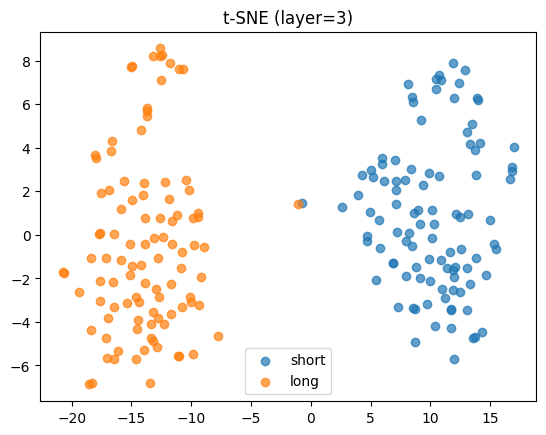

In [7]:
import json
import matplotlib.pyplot as plt

path = "./exp-final/analysis/thinking_system_re/llama3.1-8b-instruct/3.json"   # 你的 layer=0 的结果文件
N = 100

with open(path, "r") as f:
    pts = json.load(f)

x = [p[0] for p in pts]
y = [p[1] for p in pts]

plt.figure()
plt.scatter(x[:N], y[:N], label="short", alpha=0.7)
plt.scatter(x[N:], y[N:], label="long", alpha=0.7)
plt.legend()
plt.title("t-SNE (layer=3)")
plt.show()

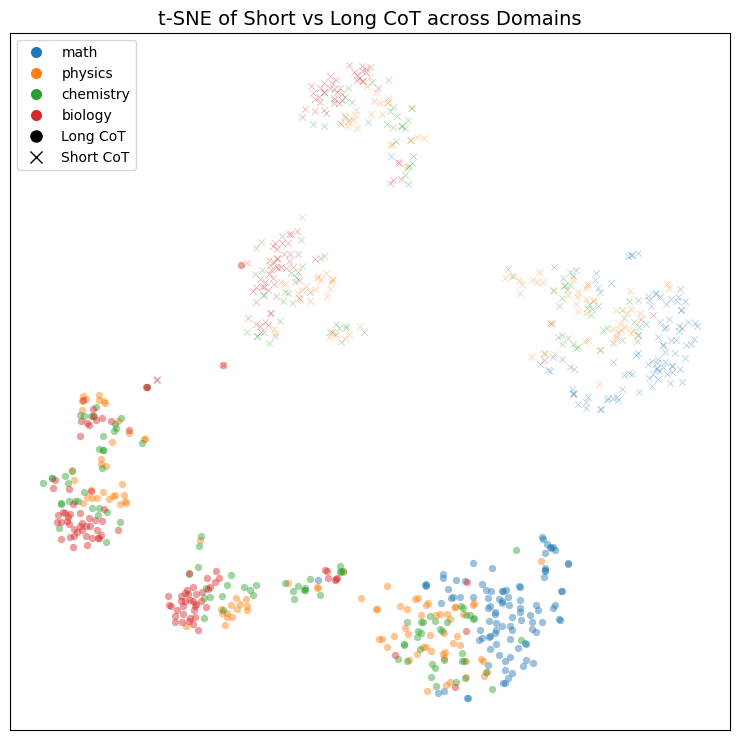

In [16]:
import json
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ===== 基本配置 =====
path = "./exp-final/analysis/domain_re_short_long/llama3.1-8b-instruct/3.json"
N = 100

colors = {
    "math": "#1f77b4",       # blue
    "physics": "#ff7f0e",    # orange
    "chemistry": "#2ca02c",  # green
    "biology": "#d62728"     # red
}

order = [
    ("math", "short"),
    ("math", "long"),
    ("physics", "short"),
    ("physics", "long"),
    ("chemistry", "short"),
    ("chemistry", "long"),
    ("biology", "short"),
    ("biology", "long"),
]

# ===== 读取数据 =====
with open(path, "r") as f:
    pts = json.load(f)

assert len(pts) == 800

# ===== 画图 =====
plt.figure(figsize=(7.5, 7.5))

idx = 0
for domain, mode in order:
    xs = [pts[i][0] for i in range(idx, idx + N)]
    ys = [pts[i][1] for i in range(idx, idx + N)]

    plt.scatter(
        xs,
        ys,
        c=colors[domain],
        s=28 if mode == "long" else 22,      # long 稍大
        alpha=0.45 if mode == "long" else 0.35,
        marker="o" if mode == "long" else "x",
        linewidths=0.6 if mode == "short" else 0,
    )
    idx += N

# ===== 自定义 legend（干净很多）=====
domain_legend = [
    Line2D([0], [0], marker='o', color='w',
           label=dom,
           markerfacecolor=col,
           markersize=9)
    for dom, col in colors.items()
]

mode_legend = [
    Line2D([0], [0], marker='o', color='k',
           label='Long CoT',
           markersize=8, linestyle='None'),
    Line2D([0], [0], marker='x', color='k',
           label='Short CoT',
           markersize=8, linestyle='None')
]

plt.legend(
    handles=domain_legend + mode_legend,
    loc="upper left",
    frameon=True
)

plt.title("t-SNE of Short vs Long CoT across Domains", fontsize=14)
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()